In [3]:
!pip install duckdb
import duckdb
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 18.7 MB/s  0:00:00 eta 0:00:01


In [6]:
!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 27.0 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 28.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [7]:
# Tier 1 (The Hub): 0 - 150 meters (roughly a 2-minute walk to the Metro turnstiles).
# Tier 2 (The Spillover): 150 - 400 meters (roughly a 5-minute walk).
# Tier 3 (Non-Metro): > 400 meters.

# The Goal: Compare the overall volume and turnover rates of Tier 1 vs. Tier 3. need to prove to stakeholders that Tier 1 stations are most critical.

1. Querying Hourly Net Flows by Metro Proximity Tier...
Data extracted successfully. Generating visualizations...


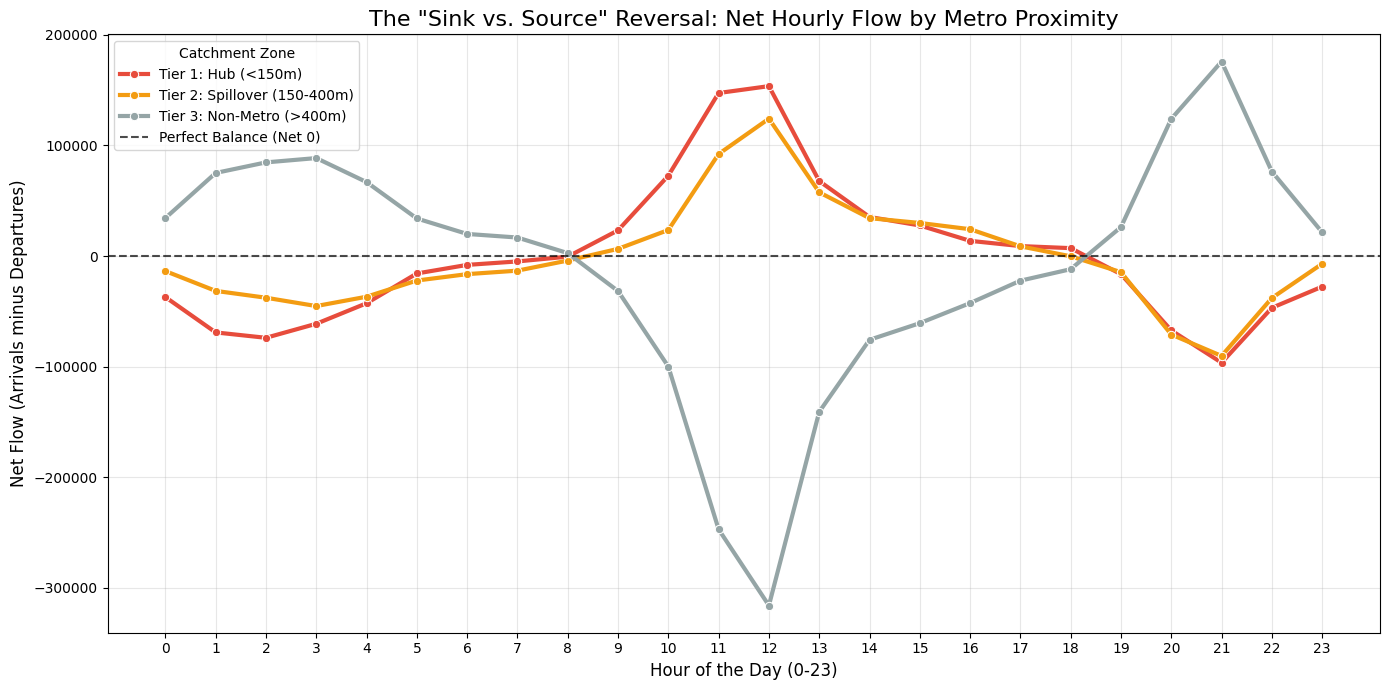


Peak 'Sink' Hours for Tier 1 (Excess Arrivals - Docks Filling Up):


,hour_of_day,arrivals,departures,net_flow
12,12,435216,281542,153674
11,11,278864,131406,147458
10,10,121558,48857,72701



Peak 'Source' Hours for Tier 1 (Excess Departures - Bikes Emptying Out):


,hour_of_day,arrivals,departures,net_flow
21,21,548978,645426,-96448
2,2,198085,272012,-73927
1,1,244341,313403,-69062


In [13]:
print("1. Querying Hourly Net Flows by Metro Proximity Tier...")

# This query assigns every station to a Tier, calculates the total arrivals (inflows) 
# and total departures (outflows) per hour, and computes the Net Flow.
query = """
WITH trips AS (
    SELECT 
        UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS start_station,
        UPPER(REGEXP_REPLACE(ENDSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS end_station,
        EXTRACT(hour FROM epoch_ms(STARTTIMEMS)) AS hour_of_day
    FROM read_csv_auto('/Users/comanetan/Downloads/EBA5006 Project/data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE STARTSTATIONNAME IS NOT NULL AND ENDSTATIONNAME IS NOT NULL
),
stations AS (
    SELECT 
        station_name_standardized,
        nearest_metro_dist_meters,
        CASE 
            WHEN nearest_metro_dist_meters <= 150 THEN 'Tier 1: Hub (<150m)'
            WHEN nearest_metro_dist_meters <= 400 THEN 'Tier 2: Spillover (150-400m)'
            ELSE 'Tier 3: Non-Metro (>400m)'
        END AS metro_tier
    FROM read_csv_auto('/Users/comanetan/Downloads/EBA5006 Project/data/Cleaned_Station_Dimension.csv', ignore_errors=true)
),
outflows AS (
    SELECT 
        s.metro_tier,
        t.hour_of_day,
        COUNT(*) AS total_departures
    FROM trips t
    JOIN stations s ON t.start_station = s.station_name_standardized
    GROUP BY s.metro_tier, t.hour_of_day
),
inflows AS (
    SELECT 
        s.metro_tier,
        t.hour_of_day,
        COUNT(*) AS total_arrivals
    FROM trips t
    JOIN stations s ON t.end_station = s.station_name_standardized
    GROUP BY s.metro_tier, t.hour_of_day
)
SELECT 
    COALESCE(o.metro_tier, i.metro_tier) AS metro_tier,
    COALESCE(o.hour_of_day, i.hour_of_day) AS hour_of_day,
    COALESCE(i.total_arrivals, 0) AS arrivals,
    COALESCE(o.total_departures, 0) AS departures,
    (COALESCE(i.total_arrivals, 0) - COALESCE(o.total_departures, 0)) AS net_flow
FROM outflows o
FULL OUTER JOIN inflows i 
    ON o.metro_tier = i.metro_tier AND o.hour_of_day = i.hour_of_day
ORDER BY metro_tier, hour_of_day
"""

flow_df = duckdb.sql(query).df()
print("Data extracted successfully. Generating visualizations...")

# 2. Plotting the Sink vs. Source Reversal
plt.figure(figsize=(14, 7))

# We use a line plot to show how Net Flow changes across the 24 hours of the day
sns.lineplot(
    data=flow_df, 
    x='hour_of_day', 
    y='net_flow', 
    hue='metro_tier',
    palette={'Tier 1: Hub (<150m)': '#e74c3c', 'Tier 2: Spillover (150-400m)': '#f39c12', 'Tier 3: Non-Metro (>400m)': '#95a5a6'},
    linewidth=3,
    marker='o'
)

# Add a baseline at 0 (Perfectly balanced: Arrivals = Departures)
plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Perfect Balance (Net 0)')

# Formatting the chart
plt.title('The "Sink vs. Source" Reversal: Net Hourly Flow by Metro Proximity', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Net Flow (Arrivals minus Departures)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='Catchment Zone')
plt.tight_layout()
plt.show()

# 3. Display the peak stress hours for Tier 1
print("\nPeak 'Sink' Hours for Tier 1 (Excess Arrivals - Docks Filling Up):")
display(flow_df[flow_df['metro_tier'] == 'Tier 1: Hub (<150m)'].nlargest(3, 'net_flow')[['hour_of_day', 'arrivals', 'departures', 'net_flow']])

print("\nPeak 'Source' Hours for Tier 1 (Excess Departures - Bikes Emptying Out):")
display(flow_df[flow_df['metro_tier'] == 'Tier 1: Hub (<150m)'].nsmallest(3, 'net_flow')[['hour_of_day', 'arrivals', 'departures', 'net_flow']])

In [14]:
# Hour 12 on the graph = 8:00 AM Montreal Time.
# Hour 21 on the graph = 5:00 PM Montreal Time.

## FINDINGS:
### 1. The Morning Commute: Metro as a "Sink" (Hour 12 / 8:00 AM)
##### What is happening: massive upward spike for the Red (Tier 1) and Orange (Tier 2) lines. A positive net flow means Arrivals completely overwhelm Departures. Commuters are waking up, grabbing bikes from the residential zones (notice how the Grey line plunges into a deep negative Source at the exact same time), and dumping them at the Metro stations.
##### The Operational Risk: Dock Exhaustion. By 8:30 AM, these Tier 1 stations are physically choking on bikes. Users trying to catch their train cannot dock their bikes, causing massive user frustration.

### 2. The Evening Commute: Metro as a "Source" (Hour 21 / 5:00 PM)
##### What is happening: system violently flips. The Red and Orange lines plunge to their lowest negative point. Departures completely overwhelm Arrivals. Commuters are stepping off the STM trains and grabbing every single bike available to ride back to their homes (which makes the Grey line spike up as a Sink).
##### The Operational Risk: Shadow Stockouts. This is exactly when the empty stations we identified earlier occur. The Tier 1 stations run completely dry, meaning late commuters have no bikes to ride home.

### 3. The "Spillover" Justification (The Orange Line)
##### for the proposed incentive program, the most important tier is Tier 2: 150-400m
##### as Orange line shadows the Red line's behavior, just at a slightly lower volume, this proves that users are willing to walk a few extra blocks to a Tier 2 station when Tier 1 is stressed.

## Justification for incentive engine: don't need a truck to move bikes at 5:00 PM; you just need to send a push notification offering users a 15% discount if they walk 3 minutes to the Orange Tier 2 stations instead of draining the Red Tier 1 stations.

1. Isolating the Mont-Royal Micro-Cluster...

2. Querying Average Daily Outflow Pressure...
3. Generating Micro-Cluster Visualization...


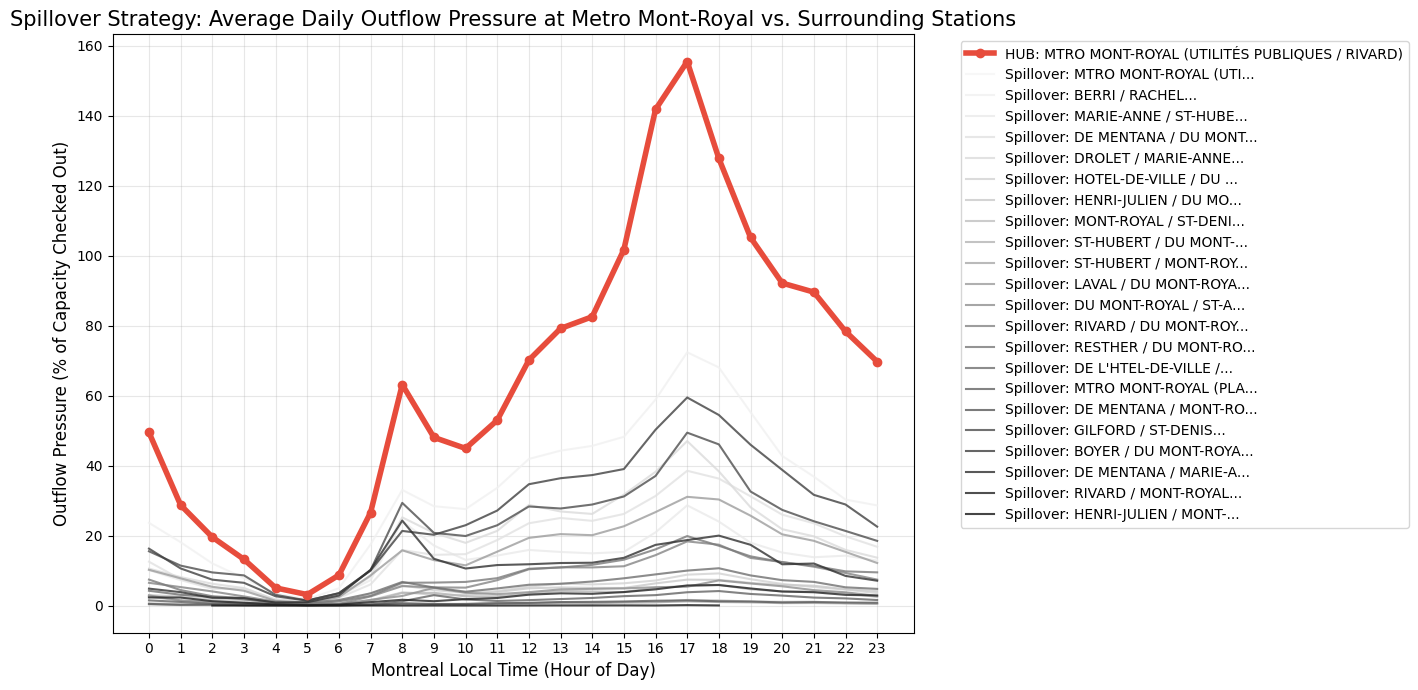

In [23]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Isolating the Mont-Royal Micro-Cluster...")

# 1. Load the station dimension table
stations_df = pd.read_csv('/Users/comanetan/Downloads/EBA5006 Project/data/Cleaned_Station_Dimension.csv')

# 2. Identify our Target Hub (Tier 1)
hub_name = 'MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)'
hub_data = stations_df[stations_df['station_name_standardized'] == hub_name].iloc[0]
hub_lat, hub_lon = hub_data['latitude'], hub_data['longitude']

# 3. Vectorized Haversine to find stations within a 400m walking radius (Tier 2)
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371000 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

stations_df['dist_to_hub'] = calculate_distance(hub_lat, hub_lon, stations_df['latitude'], stations_df['longitude'])

# Filter for the micro-cluster
cluster_df = stations_df[stations_df['dist_to_hub'] <= 400].copy()
cluster_df['role'] = np.where(cluster_df['dist_to_hub'] == 0, 'Tier 1: Hub', 'Tier 2: Spillover')

# Safely format the station names for SQL
raw_stations = cluster_df['station_name_standardized'].tolist()
sql_safe_stations = ", ".join([f"'{name.replace(chr(39), chr(39)*2)}'" for name in raw_stations])

print("\n2. Querying Average Daily Outflow Pressure...")

# UPDATED QUERY: We now calculate the total unique days and divide to get the true daily average
query = f"""
WITH trips AS (
    SELECT 
        UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS start_station,
        CAST(epoch_ms(STARTTIMEMS) - INTERVAL 4 HOUR AS DATE) AS local_date,
        EXTRACT(hour FROM (epoch_ms(STARTTIMEMS) - INTERVAL 4 HOUR)) AS local_hour
    FROM read_csv_auto('/Users/comanetan/Downloads/EBA5006 Project/data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) IN ({sql_safe_stations})
),
total_days_count AS (
    SELECT COUNT(DISTINCT local_date) AS num_days FROM trips
)
SELECT 
    start_station AS station_name_standardized,
    local_hour,
    COUNT(*) / MAX((SELECT num_days FROM total_days_count)) AS avg_daily_departures
FROM trips
GROUP BY start_station, local_hour
"""

outflow_df = duckdb.sql(query).df()

# Merge back with our cluster capacities
merged_df = outflow_df.merge(cluster_df[['station_name_standardized', 'role', 'capacity']], on='station_name_standardized')

# Calculate True Outflow Pressure (Average Hourly Departures / Physical Capacity)
merged_df['outflow_pressure_pct'] = (merged_df['avg_daily_departures'] / merged_df['capacity']) * 100

print("3. Generating Micro-Cluster Visualization...")
plt.figure(figsize=(14, 7))

# Plot the Hub with a thick, distinct line
hub_plot_data = merged_df[merged_df['role'] == 'Tier 1: Hub'].sort_values('local_hour')
plt.plot(hub_plot_data['local_hour'], hub_plot_data['outflow_pressure_pct'], 
         label=f'HUB: {hub_name}', color='#e74c3c', linewidth=4, marker='o', zorder=5)

# Plot the Spillover stations with thinner lines
spillover_stations = merged_df[merged_df['role'] == 'Tier 2: Spillover']['station_name_standardized'].unique()
colors = sns.color_palette("Greys", len(spillover_stations) + 2)

for idx, station in enumerate(spillover_stations):
    spill_data = merged_df[merged_df['station_name_standardized'] == station].sort_values('local_hour')
    plt.plot(spill_data['local_hour'], spill_data['outflow_pressure_pct'], 
             label=f'Spillover: {station[:20]}...', color=colors[idx+1], linewidth=1.5, alpha=0.8)

plt.title('Spillover Strategy: Average Daily Outflow Pressure at Metro Mont-Royal vs. Surrounding Stations', fontsize=15)
plt.xlabel('Montreal Local Time (Hour of Day)', fontsize=12)
plt.ylabel('Outflow Pressure (% of Capacity Checked Out)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()